# Оценка методов генерации упражнений

**Сравниваются 6 методов:**

| Метод | Тип | Описание |
|-------|-----|----------|
| **Fill-in-the-Blanks** | Baseline (шаблонный) | Пропуск в предложении + дистракторы по POS |
| **Sentence Reconstruction** | Baseline (шаблонный) | Перемешивание токенов предложения |
| **Qwen2.5-3B + LoRA** | Fine-tuned LLM | Генерация полных упражнений |
| **SmolLM3-3B + LoRA** | Fine-tuned LLM | Генерация полных упражнений |
| **Phi-3.5-mini + LoRA** | Fine-tuned LLM (retrained, seq=2560) | Генерация полных упражнений |
| **Claude Opus 4.7** | LLM (API) | Генерация полных упражнений |

**Метрики:**

* **LLM-методы** — `BERTScore F1`, `Perplexity`, `JSON Valid`, `Task Match`, `Items OK`, `Answers OK`
* **Шаблонные методы** — `JSON Valid`, `Task Match`, `Items OK`, `Answers OK`

В конце — сводные таблицы и графики, а также объединённая таблица
с метриками и результатами модели-судьи (`judge_quality_results.csv`).


## 1. Установка

In [1]:
# Запускать один раз (например, в Colab). Локально — можно пропустить, если пакеты уже стоят.
%pip install -q "bert-score>=0.3.13" "transformers>=4.44" torch accelerate pandas numpy matplotlib tqdm sentencepiece
print("OK")


OK


In [2]:
!pip install -q -U torchao

## 2. Импорты

In [3]:
import os, json, gc, re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

try:
    import torch
    HAS_TORCH = True
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    HAS_TORCH = False
    DEVICE = "cpu"

print("torch:", HAS_TORCH, "| device:", DEVICE)


torch: True | device: cuda


## 3. Конфигурация

In [4]:
# --- Пути к данным -----------------------------------------------------------
PRED_JSON = os.environ.get("PRED_JSON", "/content/all_predictions_300_v3.json")
JUDGE_CSV = os.environ.get("JUDGE_CSV", "/content/judge_quality_results.csv")
OUTPUT_DIR = "eval_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Какие методы к какому типу относятся -----------------------------------
LLM_MODELS      = ["qwen2.5-3b", "smollm3-3b", "phi3.5-mini", "claude-opus-4-7"]
BASELINE_MODELS = ["baseline_fib_v2", "baseline_recon_v2"]

# Базовые модели для расчёта perplexity (у claude базовой модели нет -> "—")
MODELS_BASE = {
    "qwen2.5-3b":  "Qwen/Qwen2.5-3B-Instruct",
    "smollm3-3b":  "HuggingFaceTB/SmolLM3-3B",
    "phi3.5-mini": "microsoft/Phi-3.5-mini-instruct",
}

# --- Переключатели тяжёлых шагов ---------------------------------------------
SKIP_BERTSCORE  = False   # True -> пропустить расчёт BERTScore
SKIP_PERPLEXITY = False   # True -> пропустить расчёт perplexity (грузит 3B-модели)
BERT_RESCALE    = False   # rescale_with_baseline (нужна доп. загрузка baseline-файлов)
PPL_MAX_TOKENS  = 1024    # макс. длина при расчёте perplexity

# Возможные имена ключа-эталона для BERTScore (ищется автоматически)
REFERENCE_KEYS = ["reference", "gold", "target", "target_text", "reference_text",
                  "gold_exercise", "expected", "answer_text", "gold_json", "ref"]
REFERENCE_KEY_OVERRIDE = None   # явно задать ключ эталона, если автодетект ошибётся

def is_baseline(name: str) -> bool:
    return ("baseline" in name.lower()) or (name in BASELINE_MODELS)

print("PRED_JSON :", PRED_JSON)
print("JUDGE_CSV :", JUDGE_CSV)
print("OUTPUT_DIR:", OUTPUT_DIR)


PRED_JSON : /content/all_predictions_300_v3.json
JUDGE_CSV : /content/judge_quality_results.csv
OUTPUT_DIR: eval_outputs


## 4. Загрузка данных

Файл `all_predictions_300_v3.json` может иметь разную структуру, поэтому загрузчик
автоопределяет формат и приводит данные к двум объектам:

* `all_predictions` — `dict[str, list]`: метод → список предсказаний (строки/JSON);
* `val_meta_300` — `list[dict]`: метаданные примеров (`task_type`, `error_type`, `source`, эталон).


In [5]:
def _to_text(x):
    """Предсказание может быть строкой или уже распарсенным dict/list -> строка."""
    if isinstance(x, str):
        return x
    try:
        return json.dumps(x, ensure_ascii=False)
    except Exception:
        return str(x)

def _find_pred_file(path):
    cand = [path, os.path.basename(path), os.path.join("data", os.path.basename(path)),
            os.path.join("/content", path)]
    for c in cand:
        if c and os.path.isfile(c):
            return c
    raise FileNotFoundError(
        f"Не найден файл предсказаний. Проверял: {cand}. "
        f"Задайте корректный путь в переменной PRED_JSON (ячейка 'Конфигурация')."
    )

META_FIELDS = ["task_type", "error_type", "source", "sentence", "text",
               "id", "level", "cefr"] + REFERENCE_KEYS

def load_predictions(path):
    path = _find_pred_file(path)
    print(f"Читаю: {path}")
    with open(path, "r", encoding="utf-8") as f:
        raw = json.load(f)

    all_predictions, val_meta = {}, []

    # ---- Форма A: dict {method: [...], ..., "meta": [...]} -------------------
    if isinstance(raw, dict):
        meta_key = next((k for k in ("meta", "metadata", "val_meta",
                                     "val_meta_300", "examples", "items")
                         if k in raw and isinstance(raw[k], list)), None)
        # ключи-методы = списковые значения, кроме meta-ключа
        for k, v in raw.items():
            if k == meta_key:
                continue
            if isinstance(v, list) and len(v) and not isinstance(v[0], (int, float)):
                # список предсказаний?
                if all(isinstance(e, (str, dict, list)) for e in v):
                    all_predictions[k] = [_to_text(e) for e in v]
        if meta_key is not None:
            val_meta = [m if isinstance(m, dict) else {} for m in raw[meta_key]]
        # вложенный вариант: {"predictions": {...}, "meta": [...]}
        if not all_predictions and "predictions" in raw and isinstance(raw["predictions"], dict):
            for k, v in raw["predictions"].items():
                all_predictions[k] = [_to_text(e) for e in v]

    # ---- Форма B: list[record] ---------------------------------------------
    elif isinstance(raw, list):
        n = len(raw)
        # собрать множество имён методов
        method_names = set()
        for rec in raw:
            if not isinstance(rec, dict):
                continue
            for pk in ("predictions", "outputs", "generations", "preds"):
                if isinstance(rec.get(pk), dict):
                    method_names |= set(rec[pk].keys())
            for k, v in rec.items():
                if k in META_FIELDS:
                    continue
                if isinstance(v, (str, dict, list)) and k not in (
                        "predictions", "outputs", "generations", "preds"):
                    # эвристика: ключ похож на метод
                    if is_baseline(k) or k in LLM_MODELS or "claude" in k or \
                       any(m in k for m in ("qwen", "smol", "phi", "baseline")):
                        method_names.add(k)
        method_names = sorted(method_names)
        all_predictions = {m: [] for m in method_names}
        for rec in raw:
            rec = rec if isinstance(rec, dict) else {}
            meta = {k: rec.get(k) for k in META_FIELDS if k in rec}
            val_meta.append(meta)
            sub = {}
            for pk in ("predictions", "outputs", "generations", "preds"):
                if isinstance(rec.get(pk), dict):
                    sub = rec[pk]
                    break
            for m in method_names:
                if m in sub:
                    all_predictions[m].append(_to_text(sub[m]))
                elif m in rec:
                    all_predictions[m].append(_to_text(rec[m]))
                else:
                    all_predictions[m].append("")
        # выкинуть полностью пустые методы
        all_predictions = {m: v for m, v in all_predictions.items()
                            if any(s.strip() for s in v)}
    else:
        raise ValueError(f"Неизвестная структура JSON: {type(raw)}")

    # если meta не нашли, но методы есть — создаём заглушки нужной длины
    if not val_meta and all_predictions:
        n = len(next(iter(all_predictions.values())))
        val_meta = [{} for _ in range(n)]

    return all_predictions, val_meta


all_predictions, val_meta_300 = load_predictions(PRED_JSON)

# ---- Диагностика структуры --------------------------------------------------
print("\nНайдено методов:", len(all_predictions))
for k, v in all_predictions.items():
    print(f"  {k:<22} n={len(v)}")
print("\nПримеров (val_meta_300):", len(val_meta_300))
if val_meta_300:
    print("Ключи метаданных:", sorted(val_meta_300[0].keys()))

# ---- Порядок / классификация методов ---------------------------------------
present = list(all_predictions.keys())
ordered = [m for m in LLM_MODELS + BASELINE_MODELS if m in present]
ordered += [m for m in present if m not in ordered]
LLM_PRESENT  = [m for m in ordered if not is_baseline(m)]
BASE_PRESENT = [m for m in ordered if is_baseline(m)]
ALL_METHODS  = LLM_PRESENT + BASE_PRESENT
all_names    = ALL_METHODS

print("\nLLM-методы     :", LLM_PRESENT)
print("Шаблонные методы:", BASE_PRESENT)


Читаю: /content/all_predictions_300_v3.json

Найдено методов: 6
  qwen2.5-3b             n=300
  smollm3-3b             n=300
  phi3.5-mini            n=300
  baseline_fib_v2        n=300
  baseline_recon_v2      n=300
  claude-opus-4-7        n=300

Примеров (val_meta_300): 300
Ключи метаданных: []

LLM-методы     : ['qwen2.5-3b', 'smollm3-3b', 'phi3.5-mini', 'claude-opus-4-7']
Шаблонные методы: ['baseline_fib_v2', 'baseline_recon_v2']


In [6]:
VAL_JSONL = os.environ.get('VAL_JSONL', '/content/val.jsonl')
VAL_META  = os.environ.get('VAL_META',  '/content/val_meta.json')

def _find_first(*cands):
    for c in cands:
        if c and os.path.isfile(c):
            return c
    return None

vmeta_path  = _find_first(VAL_META,  os.path.basename(VAL_META),
                          os.path.join('data', os.path.basename(VAL_META)),
                          os.path.join('/content', VAL_META))
vjsonl_path = _find_first(VAL_JSONL, os.path.basename(VAL_JSONL),
                          os.path.join('data', os.path.basename(VAL_JSONL)),
                          os.path.join('/content', VAL_JSONL))

meta_rows = []
if vmeta_path:
    with open(vmeta_path, 'r', encoding='utf-8') as f:
        meta_rows = json.load(f)
    print(f'val_meta.json: {vmeta_path}  | {len(meta_rows)} записей')
else:
    print('⚠ val_meta.json не найден')

ref_rows = []
if vjsonl_path:
    with open(vjsonl_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)
            # эталон = последний assistant-ответ
            ref = ''
            for m in obj.get('messages', []):
                if m.get('role') == 'assistant':
                    ref = m.get('content', '') or ''
            ref_rows.append(ref)
    print(f'val.jsonl     : {vjsonl_path}  | {len(ref_rows)} эталонов')
else:
    print('⚠ val.jsonl не найден — BERTScore останется без эталонов')

# Сшиваем по индексу. Предполагаем, что порядок val_meta.json и val.jsonl
# совпадает с порядком предсказаний (так оно и было при генерации).
n_pred = len(next(iter(all_predictions.values()))) if all_predictions else 0
n      = max(n_pred, len(meta_rows), len(ref_rows))
new_meta = []
for i in range(n):
    row = dict(meta_rows[i]) if i < len(meta_rows) and isinstance(meta_rows[i], dict) else {}
    if i < len(ref_rows) and ref_rows[i]:
        row['reference'] = ref_rows[i]   # ключ из REFERENCE_KEYS
    new_meta.append(row)

# Перезаписываем val_meta_300
val_meta_300 = new_meta[:n_pred] if n_pred else new_meta

# --- Диагностика ------------------------------------------------------------
keys_seen = set()
for m in val_meta_300:
    if isinstance(m, dict):
        keys_seen |= set(m.keys())
n_ref = sum(1 for m in val_meta_300 if isinstance(m, dict) and m.get('reference'))
print(f'\nval_meta_300: {len(val_meta_300)} записей')
print(f'Ключи: {sorted(keys_seen)}')
print(f'С эталоном (reference): {n_ref}/{len(val_meta_300)}')

val_meta.json: /content/val_meta.json  | 300 записей
val.jsonl     : /content/val.jsonl  | 300 эталонов

val_meta_300: 300 записей
Ключи: ['error_type', 'record_id', 'reference', 'source', 'target', 'task_type']
С эталоном (reference): 300/300


## 5. Эталоны для BERTScore

`BERTScore` сравнивает сгенерированный текст с эталоном. Ключ эталона ищется
автоматически среди `REFERENCE_KEYS`; при необходимости задайте его вручную через
`REFERENCE_KEY_OVERRIDE` в ячейке «Конфигурация».

In [7]:
def detect_reference_key(meta_list):
    if REFERENCE_KEY_OVERRIDE:
        return REFERENCE_KEY_OVERRIDE
    for key in REFERENCE_KEYS:
        if any(isinstance(m, dict) and m.get(key) for m in meta_list):
            return key
    return None

REF_KEY = detect_reference_key(val_meta_300)

def get_reference(meta):
    if REF_KEY and isinstance(meta, dict) and meta.get(REF_KEY) is not None:
        return _to_text(meta[REF_KEY])
    return None

n_ref = sum(get_reference(m) is not None for m in val_meta_300)
if REF_KEY:
    print(f"Ключ эталона: '{REF_KEY}'  |  эталонов: {n_ref}/{len(val_meta_300)}")
else:
    print("⚠ Эталон не найден — BERTScore будет пропущен.")
    print("  Укажите REFERENCE_KEY_OVERRIDE в ячейке «Конфигурация», если эталон есть.")
    SKIP_BERTSCORE = True


Ключ эталона: 'reference'  |  эталонов: 300/300


## 6. BERTScore F1 — только LLM

In [9]:
bertscore_results = {}

if SKIP_BERTSCORE:
    print("BERTScore пропущен (SKIP_BERTSCORE=True или нет эталонов).")
else:
    from bert_score import score as bert_score_fn

    for name in LLM_PRESENT:
        preds = all_predictions.get(name, [])
        cands, refs = [], []
        for pred, meta in zip(preds, val_meta_300):
            ref = get_reference(meta)
            if ref is None or not str(pred).strip():
                continue
            cands.append(str(pred))
            refs.append(str(ref))
        if not cands:
            print(f"  {name}: нет пар (pred, ref) — пропуск")
            continue
        P, R, F1 = bert_score_fn(
            cands, refs, lang="en",
            rescale_with_baseline=BERT_RESCALE,
            verbose=False,
            device=DEVICE if HAS_TORCH else None,
        )
        f1 = F1.mean().item()
        f1_std = F1.std().item()
        bertscore_results[name] = {"f1": f1, "f1_std": f1_std, "n": len(cands)}
        print(f"  {name:<18} F1={f1:.4f} ± {f1_std:.4f}  (n={len(cands)})")

    if HAS_TORCH and DEVICE == "cuda":
        torch.cuda.empty_cache()


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  qwen2.5-3b         F1=0.9137 ± 0.0250  (n=300)


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  phi3.5-mini        F1=0.8250 ± 0.0132  (n=300)


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  claude-opus-4-7    F1=0.8977 ± 0.0226  (n=300)


## 7. Perplexity — только LLM

Перплексия генерируемого текста под соответствующей **базовой** моделью
(`MODELS_BASE`). Для `claude-opus-4-7` базовой модели нет → значение `—`.

In [8]:
# --- Perplexity: LoRA-модель на эталонных val-диалогах -----------------------
# Согласованно с eval_300.ipynb:
#   * грузим базу + LoRA-адаптер (PeftModel.from_pretrained)
#   * скармливаем полные диалоги val.jsonl через apply_chat_template
#   * корпусная PPL: exp(Σ loss·tokens / Σ tokens) — не среднее по примерам
# Phi-3.5: trust_remote_code=False + attn_implementation="eager", иначе
# падает на DynamicCache.from_legacy_cache (transformers >= 4.46).

import shutil
from transformers import AutoModelForCausalLM, AutoTokenizer
try:
    from peft import PeftModel
    HAS_PEFT = True
except ImportError:
    HAS_PEFT = False
    print("⚠ peft не установлен — выполните: pip install peft")

# 1) val_records_300: полные диалоги из val.jsonl
def _load_val_records(path):
    for c in [path, os.path.basename(path),
              os.path.join('data', os.path.basename(path)),
              os.path.join('/content', path),
              os.path.join('/content', os.path.basename(path))]:
        if c and os.path.isfile(c):
            with open(c, 'r', encoding='utf-8') as f:
                return [json.loads(ln) for ln in f if ln.strip()]
    return []

val_records_300 = _load_val_records(os.environ.get('VAL_JSONL', 'data/dataset/val.jsonl'))
print(f"val_records_300: {len(val_records_300)} диалогов")

# 2) Локации адаптеров
def _find_adapter(name):
    for c in [f"adapters/{name}", f"../adapters/{name}",
              f"/content/adapters/{name}", f"/content/drive/MyDrive/SAYIT_Диплом/adapters/{name}"]:
        if os.path.isdir(c):
            return c
    return None

ADAPTER_DIRS = {n: _find_adapter(n) for n in MODELS_BASE}
for n, p in ADAPTER_DIRS.items():
    print(f"  {n:<18} {('✓ ' + p) if p else '✗ адаптер не найден'}")

HF_CACHE    = os.path.expanduser("~/.cache/huggingface/hub")
PPL_MAX_LEN = 2560  # как в eval_300.ipynb
CLEAR_HF_CACHE_BETWEEN_MODELS = False  # включить True, если мало места на диске

def compute_perplexity(base_name, adapter_dir, name, val_records):
    is_phi = "phi" in name.lower()
    trust  = not is_phi
    extra  = {"attn_implementation": "eager"} if is_phi else {}

    tok_src = adapter_dir if adapter_dir else base_name
    tokenizer = AutoTokenizer.from_pretrained(tok_src, trust_remote_code=trust)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    base_model = AutoModelForCausalLM.from_pretrained(
        base_name, device_map={"": 0}, trust_remote_code=trust,
        torch_dtype=torch.float16, **extra,
    )
    if adapter_dir and HAS_PEFT:
        model = PeftModel.from_pretrained(base_model, adapter_dir)
    else:
        model = base_model
    model.eval()

    total_loss, total_tokens = 0.0, 0
    skipped = 0
    for rec in tqdm(val_records, desc=f"  PPL {name}", unit="ex", leave=False):
        try:
            text = tokenizer.apply_chat_template(
                rec["messages"], tokenize=False, add_generation_prompt=False
            )
        except Exception:
            skipped += 1
            continue
        enc = tokenizer(text, return_tensors="pt", truncation=True, max_length=PPL_MAX_LEN)
        input_ids = enc["input_ids"].to(model.device)
        if input_ids.size(1) < 2:
            skipped += 1
            continue
        with torch.no_grad():
            # use_cache=False — для loss-only forward кэш не нужен (страховка для Phi-3.5)
            out = model(input_ids=input_ids, labels=input_ids, use_cache=False)
            total_loss   += float(out.loss) * input_ids.shape[1]
            total_tokens += input_ids.shape[1]

    del model
    if adapter_dir and HAS_PEFT:
        del base_model
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

    if total_tokens == 0:
        return None
    return {
        "perplexity": float(np.exp(total_loss / total_tokens)),
        "avg_loss":   total_loss / total_tokens,
        "n":          len(val_records) - skipped,
        "skipped":    skipped,
    }

# 3) Прогон по LLM-методам (claude пропускаем — нет адаптера/базы)
perplexity_results = {}  # пересчитываем все модели единообразно

if SKIP_PERPLEXITY or not HAS_TORCH or not val_records_300:
    print("Perplexity пропущена (SKIP_PERPLEXITY / нет torch / нет val_records).")
else:
    for name in LLM_PRESENT:
        base = MODELS_BASE.get(name)
        if base is None:
            print(f"  {name:<18} — (нет базовой модели в MODELS_BASE)")
            continue
        if not ADAPTER_DIRS.get(name):
            print(f"  {name:<18} — пропуск (адаптер не найден)")
            continue
        try:
            print(f"\nPPL для {name}  (base={base}, lora={ADAPTER_DIRS[name]})")
            if CLEAR_HF_CACHE_BETWEEN_MODELS and os.path.exists(HF_CACHE):
                shutil.rmtree(HF_CACHE)
            res = compute_perplexity(base, ADAPTER_DIRS[name], name, val_records_300)
            if res:
                perplexity_results[name] = res
                print(f"  {name:<18} PPL={res['perplexity']:.2f}  "
                      f"(loss={res['avg_loss']:.3f}, n={res['n']}, skipped={res['skipped']})")
        except Exception as e:
            print(f"  {name}: ошибка perplexity -> {e}")

print("\nИтоговый perplexity_results:")
for k, v in perplexity_results.items():
    print(f"  {k:<18} PPL={v['perplexity']:.2f}")


val_records_300: 300 диалогов
  qwen2.5-3b         ✓ /content/drive/MyDrive/SAYIT_Диплом/adapters/qwen2.5-3b
  smollm3-3b         ✓ /content/drive/MyDrive/SAYIT_Диплом/adapters/smollm3-3b
  phi3.5-mini        ✓ /content/drive/MyDrive/SAYIT_Диплом/adapters/phi3.5-mini

PPL для qwen2.5-3b  (base=Qwen/Qwen2.5-3B-Instruct, lora=/content/drive/MyDrive/SAYIT_Диплом/adapters/qwen2.5-3b)


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

  PPL qwen2.5-3b:   0%|          | 0/300 [00:00<?, ?ex/s]

  qwen2.5-3b         PPL=1.22  (loss=0.199, n=300, skipped=0)

PPL для smollm3-3b  (base=HuggingFaceTB/SmolLM3-3B, lora=/content/drive/MyDrive/SAYIT_Диплом/adapters/smollm3-3b)


...

  smollm3-3b         PPL=1.23  (loss=0.211, n=300, skipped=0)

PPL для phi3.5-mini  (base=microsoft/Phi-3.5-mini-instruct, lora=/content/drive/MyDrive/SAYIT_Диплом/adapters/phi3.5-mini)


This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

  PPL phi3.5-mini:   0%|          | 0/300 [00:00<?, ?ex/s]

  phi3.5-mini        PPL=4.70  (loss=1.548, n=300, skipped=0)
  claude-opus-4-7    — (нет базовой модели в MODELS_BASE)

Итоговый perplexity_results:
  qwen2.5-3b         PPL=1.22
  smollm3-3b         PPL=1.23
  phi3.5-mini        PPL=4.70


## 8. Task-метрики — все методы

`JSON Valid`, `Task Match`, `Items OK`, `Answers OK` (доли от числа примеров).

In [10]:
ITEM_COUNT_RANGES = {
    "grammar_choice": (10, 14), "transformation": (8, 12),
    "vocabulary_fill": (10, 20), "functional_match": (8, 10),
    "functional_matching": (8, 10), "matching": (8, 16),
    "reading_tf": (8, 8), "writing_sample": (1, 1)
}

def _parse_pred(pred):
    """Строка/JSON -> dict | None."""
    if isinstance(pred, dict):
        return pred
    raw = str(pred).strip()
    if not raw:
        return None
    if raw.startswith("```"):
        parts = raw.split("```")
        if len(parts) > 1:
            raw = parts[1]
        if raw.startswith("json"):
            raw = raw[4:]
    try:
        return json.loads(raw)
    except (json.JSONDecodeError, IndexError, ValueError):
        return None

def evaluate_task_relevance(predictions, val_meta):
    keys = ["json_valid", "task_type_match", "items_count_ok", "has_answers"]
    counts = {k: 0 for k in keys}
    total = max(len(predictions), 1)
    for pred, meta in zip(predictions, val_meta):
        data = _parse_pred(pred)
        if data is None:
            continue
        counts["json_valid"] += 1

        requested = (meta or {}).get("task_type", "") or ""
        generated = data.get("task", {}).get("type", "") if isinstance(data, dict) else ""
        if generated and generated.replace("_", "") == str(requested).replace("_", ""):
            counts["task_type_match"] += 1

        items = []
        if isinstance(data, dict):
            items = data.get("task", {}).get("content_en", {}).get("items", []) or []
        lo, hi = ITEM_COUNT_RANGES.get(generated, (1, 30))
        if lo <= len(items) <= hi:
            counts["items_count_ok"] += 1
        if items and all(it.get("student_answer_en") for it in items
                         if isinstance(it, dict)):
            counts["has_answers"] += 1
    return {k: counts[k] / total for k in keys}

task_relevance_results = {}
for name in ALL_METHODS:
    tr = evaluate_task_relevance(all_predictions[name], val_meta_300)
    task_relevance_results[name] = tr
    print(f"\n{name}:")
    for k, v in tr.items():
        print(f"  {k:<16} {v:.1%}")



qwen2.5-3b:
  json_valid       98.7%
  task_type_match  85.3%
  items_count_ok   86.3%
  has_answers      95.0%

smollm3-3b:
  json_valid       96.0%
  task_type_match  83.7%
  items_count_ok   85.7%
  has_answers      94.0%

phi3.5-mini:
  json_valid       80.7%
  task_type_match  80.0%
  items_count_ok   1.0%
  has_answers      80.0%

claude-opus-4-7:
  json_valid       100.0%
  task_type_match  100.0%
  items_count_ok   100.0%
  has_answers      100.0%

baseline_fib_v2:
  json_valid       100.0%
  task_type_match  27.3%
  items_count_ok   100.0%
  has_answers      100.0%

baseline_recon_v2:
  json_valid       100.0%
  task_type_match  25.0%
  items_count_ok   100.0%
  has_answers      100.0%


## 9. Сводная таблица метрик

In [11]:
def _fmt(x, pct=False):
    if x is None:
        return "—"
    return f"{x:.1%}" if pct else f"{x:.4f}"

rows = []
for name in ALL_METHODS:
    tr = task_relevance_results.get(name, {})
    bs = bertscore_results.get(name)
    pp = perplexity_results.get(name)
    rows.append({
        "Метод": name,
        "Тип": "Baseline" if is_baseline(name) else "LLM",
        "BERTScore F1": _fmt(bs["f1"]) if bs else "—",
        "Perplexity":   f"{pp['perplexity']:.2f}" if pp else "—",
        "JSON Valid":   _fmt(tr.get("json_valid"), pct=True),
        "Task Match":   _fmt(tr.get("task_type_match"), pct=True),
        "Items OK":     _fmt(tr.get("items_count_ok"), pct=True),
        "Answers OK":   _fmt(tr.get("has_answers"), pct=True),
    })

comparison_df = pd.DataFrame(rows).set_index("Метод")
print(comparison_df.to_string())
comparison_df.to_csv(os.path.join(OUTPUT_DIR, "model_comparison_v3.csv"),
                     encoding="utf-8-sig")
print(f"\n✓ {OUTPUT_DIR}/model_comparison_v3.csv")
comparison_df


                        Тип BERTScore F1 Perplexity JSON Valid Task Match Items OK Answers OK
Метод                                                                                        
qwen2.5-3b              LLM       0.9137       1.22      98.7%      85.3%    86.3%      95.0%
smollm3-3b              LLM       0.9145       1.23      96.0%      83.7%    85.7%      94.0%
phi3.5-mini             LLM       0.8250       4.70      80.7%      80.0%     1.0%      80.0%
claude-opus-4-7         LLM       0.8977          —     100.0%     100.0%   100.0%     100.0%
baseline_fib_v2    Baseline            —          —     100.0%      27.3%   100.0%     100.0%
baseline_recon_v2  Baseline            —          —     100.0%      25.0%   100.0%     100.0%

✓ eval_outputs/model_comparison_v3.csv


,Тип,BERTScore F1,Perplexity,JSON Valid,Task Match,Items OK,Answers OK
Метод,,,,,,,
qwen2.5-3b,LLM,0.9137,1.22,98.7%,85.3%,86.3%,95.0%
smollm3-3b,LLM,0.9145,1.23,96.0%,83.7%,85.7%,94.0%
phi3.5-mini,LLM,0.8250,4.70,80.7%,80.0%,1.0%,80.0%
claude-opus-4-7,LLM,0.8977,—,100.0%,100.0%,100.0%,100.0%
baseline_fib_v2,Baseline,—,—,100.0%,27.3%,100.0%,100.0%
baseline_recon_v2,Baseline,—,—,100.0%,25.0%,100.0%,100.0%


## 10. Визуализация метрик

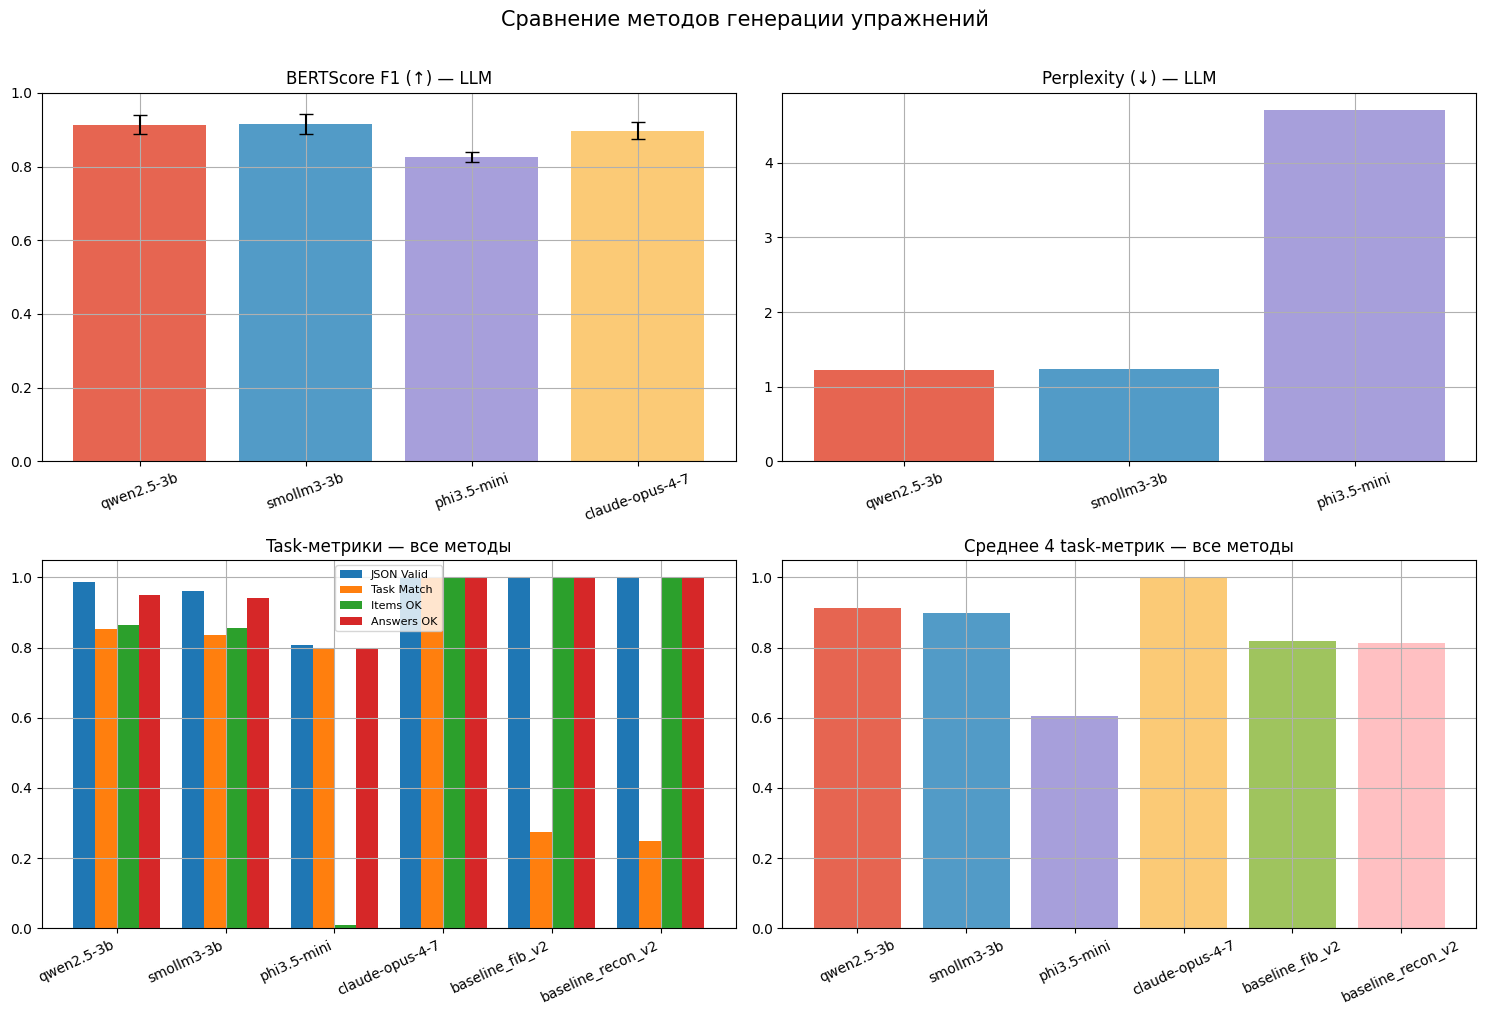

✓ eval_outputs/metrics_comparison.png


In [12]:
plt.rcParams["axes.grid"] = True
COL = {"qwen2.5-3b": "#E24A33", "smollm3-3b": "#348ABD", "phi3.5-mini": "#988ED5",
       "claude-opus-4-7": "#FBC15E", "baseline_fib_v2": "#8EBA42",
       "baseline_recon_v2": "#FFB5B8"}
def colors_for(names):
    return [COL.get(n, "#777777") for n in names]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# (1) BERTScore F1 — LLM
ax = axes[0, 0]
bn = [n for n in LLM_PRESENT if n in bertscore_results]
if bn:
    vals = [bertscore_results[n]["f1"] for n in bn]
    stds = [bertscore_results[n]["f1_std"] for n in bn]
    ax.bar(bn, vals, yerr=stds, color=colors_for(bn), alpha=0.85, capsize=5)
    ax.set_ylim(0, 1)
ax.set_title("BERTScore F1 (↑) — LLM")
ax.tick_params(axis="x", rotation=20)

# (2) Perplexity — LLM
ax = axes[0, 1]
pn = [n for n in LLM_PRESENT if n in perplexity_results]
if pn:
    pv = [perplexity_results[n]["perplexity"] for n in pn]
    ax.bar(pn, pv, color=colors_for(pn), alpha=0.85)
ax.set_title("Perplexity (↓) — LLM")
ax.tick_params(axis="x", rotation=20)

# (3) Task-метрики — все методы (сгруппированный bar)
ax = axes[1, 0]
metrics = [("json_valid", "JSON Valid"), ("task_type_match", "Task Match"),
           ("items_count_ok", "Items OK"), ("has_answers", "Answers OK")]
x = np.arange(len(ALL_METHODS))
w = 0.2
for i, (key, label) in enumerate(metrics):
    vals = [task_relevance_results[m].get(key, 0) for m in ALL_METHODS]
    ax.bar(x + (i - 1.5) * w, vals, w, label=label)
ax.set_xticks(x)
ax.set_xticklabels(ALL_METHODS, rotation=25, ha="right")
ax.set_ylim(0, 1.05)
ax.set_title("Task-метрики — все методы")
ax.legend(fontsize=8)

# (4) Composite (среднее 4 метрик) — все методы
ax = axes[1, 1]
comp = [np.mean([task_relevance_results[m].get(k, 0) for k, _ in metrics])
        for m in ALL_METHODS]
ax.bar(ALL_METHODS, comp, color=colors_for(ALL_METHODS), alpha=0.85)
ax.set_ylim(0, 1.05)
ax.set_title("Среднее 4 task-метрик — все методы")
ax.tick_params(axis="x", rotation=25)

plt.suptitle("Сравнение методов генерации упражнений", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "metrics_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ {OUTPUT_DIR}/metrics_comparison.png")


## 11. Результаты модели-судьи (LLM-as-judge)

Загрузка `judge_quality_results.csv`, агрегация по методу (среднее) и
столбчатая диаграмма по каждому критерию качества.

In [13]:
def _find_judge_csv(path):
    for c in [path, os.path.basename(path),
              os.path.join("data", os.path.basename(path)),
              os.path.join("/content", path)]:
        if c and os.path.isfile(c):
            return c
    return None

judge_df = None
judge_agg = None
JUDGE_METRIC_COLS = []

jpath = _find_judge_csv(JUDGE_CSV)
if jpath is None:
    print(f"⚠ Не найден {JUDGE_CSV}. Раздел judge пропущен.")
else:
    judge_df = pd.read_csv(jpath)
    print(f"Читаю: {jpath}  | строк: {len(judge_df)}  | колонки: {list(judge_df.columns)}")
    display(judge_df.head())

    # колонка метода
    cand_cols = [c for c in judge_df.columns
                 if c.lower() in ("model", "method", "name", "system",
                                  "метод", "модель")]
    if not cand_cols:
        # колонка, чьи значения пересекаются с именами методов
        for c in judge_df.columns:
            if judge_df[c].dtype == object:
                vals = set(judge_df[c].astype(str))
                if vals & set(ALL_METHODS):
                    cand_cols = [c]
                    break
    method_col = cand_cols[0] if cand_cols else judge_df.columns[0]

    JUDGE_METRIC_COLS = [c for c in judge_df.columns
                         if c != method_col
                         and pd.api.types.is_numeric_dtype(judge_df[c])]
    print(f"\nКолонка метода: '{method_col}'")
    print(f"Числовые критерии судьи: {JUDGE_METRIC_COLS}")

    judge_agg = (judge_df.groupby(method_col)[JUDGE_METRIC_COLS]
                 .mean().round(4))
    # упорядочить как ALL_METHODS (плюс прочие в конце)
    order = [m for m in ALL_METHODS if m in judge_agg.index]
    order += [m for m in judge_agg.index if m not in order]
    judge_agg = judge_agg.loc[order]
    print("\nАгрегировано по методу (среднее):")
    display(judge_agg)


Читаю: /content/judge_quality_results.csv  | строк: 6  | колонки: ['model', 'judged_ok', 'judge_fail', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'criteria_mean_0_1', 'acceptance_score', 'pct_accept_as_is', 'pct_usable', 'pct_reject', 'top_failure']


,model,judged_ok,judge_fail,C1,C2,C3,C4,C5,C6,C7,criteria_mean_0_1,acceptance_score,pct_accept_as_is,pct_usable,pct_reject,top_failure
0,qwen2.5-3b,300,0,1.773,1.610,1.057,1.033,0.720,0.837,1.287,0.5941,0.1550,0.0233,0.2867,0.7133,off_target
1,claude-opus-4-7,300,0,1.967,1.943,1.840,1.383,1.237,1.253,1.820,0.8174,0.4500,0.2033,0.6967,0.3033,off_target
2,smollm3-3b,300,0,1.787,1.603,0.853,0.993,0.760,0.790,1.237,0.5731,0.1333,0.0367,0.2300,0.7700,off_target
3,phi3.5-mini,300,0,1.377,0.677,0.660,0.697,0.710,0.403,0.133,0.3326,0.0033,0.0000,0.0067,0.9933,malformed_structure
4,baseline_fib_v2,300,0,1.390,1.223,1.083,0.380,0.017,0.540,0.840,0.3909,0.0000,0.0000,0.0000,1.0000,off_target



Колонка метода: 'model'
Числовые критерии судьи: ['judged_ok', 'judge_fail', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'criteria_mean_0_1', 'acceptance_score', 'pct_accept_as_is', 'pct_usable', 'pct_reject']

Агрегировано по методу (среднее):


,judged_ok,judge_fail,C1,C2,C3,C4,C5,C6,C7,criteria_mean_0_1,acceptance_score,pct_accept_as_is,pct_usable,pct_reject
model,,,,,,,,,,,,,,
qwen2.5-3b,300.0,0.0,1.773,1.610,1.057,1.033,0.720,0.837,1.287,0.5941,0.1550,0.0233,0.2867,0.7133
smollm3-3b,300.0,0.0,1.787,1.603,0.853,0.993,0.760,0.790,1.237,0.5731,0.1333,0.0367,0.2300,0.7700
phi3.5-mini,300.0,0.0,1.377,0.677,0.660,0.697,0.710,0.403,0.133,0.3326,0.0033,0.0000,0.0067,0.9933
claude-opus-4-7,300.0,0.0,1.967,1.943,1.840,1.383,1.237,1.253,1.820,0.8174,0.4500,0.2033,0.6967,0.3033
baseline_fib_v2,300.0,0.0,1.390,1.223,1.083,0.380,0.017,0.540,0.840,0.3909,0.0000,0.0000,0.0000,1.0000
baseline_recon_v2,300.0,0.0,1.423,1.147,1.110,2.000,0.003,0.153,0.670,0.4647,0.0000,0.0000,0.0000,1.0000


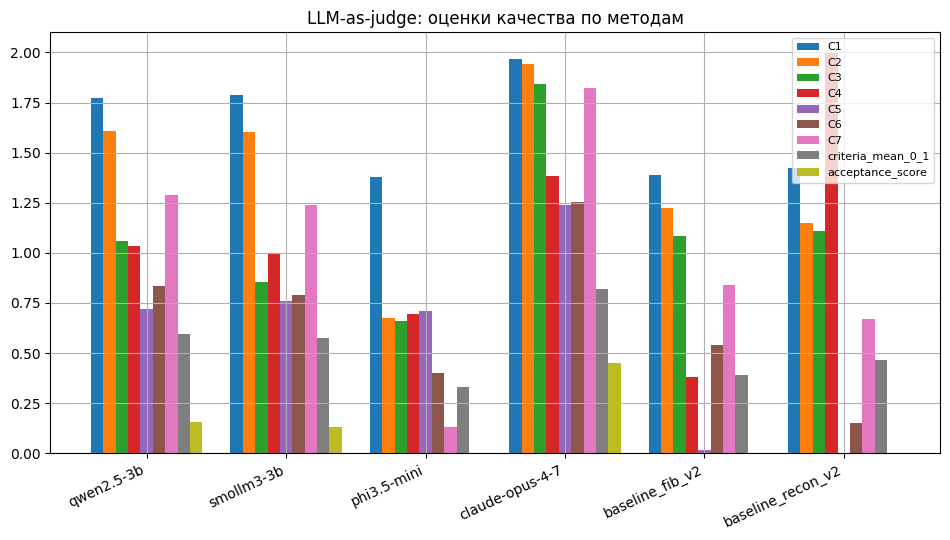

✓ eval_outputs/judge_quality.png
  показано столбцов: ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'criteria_mean_0_1', 'acceptance_score']
  скрыто из графика: ['judged_ok', 'judge_fail', 'pct_accept_as_is', 'pct_usable', 'pct_reject']


In [15]:
# Какие столбцы НЕ показываем на графике (счётчики и % статуса акцепта).
# Combined-таблица в следующей секции по-прежнему получает полный JUDGE_METRIC_COLS.
JUDGE_PLOT_EXCLUDE = {
    "judged_ok", "judge_fail",
    "pct_accept_as_is", "pct_usable", "pct_reject",
}
plot_cols = [c for c in JUDGE_METRIC_COLS if c not in JUDGE_PLOT_EXCLUDE]

if judge_agg is not None and plot_cols:
    methods = list(judge_agg.index)
    x = np.arange(len(methods))
    w = 0.8 / max(len(plot_cols), 1)
    fig, ax = plt.subplots(figsize=(max(9, len(methods) * 1.6), 5.5))
    for i, col in enumerate(plot_cols):
        ax.bar(x + (i - (len(plot_cols) - 1) / 2) * w,
               judge_agg[col].values, w, label=str(col))
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=25, ha="right")
    ax.set_title("LLM-as-judge: оценки качества по методам")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "judge_quality.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ {OUTPUT_DIR}/judge_quality.png")
    print(f"  показано столбцов: {plot_cols}")
    skipped = [c for c in JUDGE_METRIC_COLS if c in JUDGE_PLOT_EXCLUDE]
    if skipped:
        print(f"  скрыто из графика: {skipped}")
else:
    print("Нет данных судьи для графика.")


## 12. Общая таблица: метрики + judge

Объединённая таблица по всем методам (LLM и шаблонным): автоматические метрики
плюс агрегированные оценки модели-судьи.

In [16]:
combined_rows = []
for name in ALL_METHODS:
    tr = task_relevance_results.get(name, {})
    bs = bertscore_results.get(name)
    pp = perplexity_results.get(name)
    row = {
        "Метод": name,
        "Тип": "Baseline" if is_baseline(name) else "LLM",
        "BERTScore F1": round(bs["f1"], 4) if bs else np.nan,
        "Perplexity":   round(pp["perplexity"], 2) if pp else np.nan,
        "JSON Valid":   round(tr.get("json_valid", 0), 4),
        "Task Match":   round(tr.get("task_type_match", 0), 4),
        "Items OK":     round(tr.get("items_count_ok", 0), 4),
        "Answers OK":   round(tr.get("has_answers", 0), 4),
    }
    if judge_agg is not None and name in judge_agg.index:
        for col in JUDGE_METRIC_COLS:
            row[f"judge_{col}"] = judge_agg.loc[name, col]
    else:
        for col in JUDGE_METRIC_COLS:
            row[f"judge_{col}"] = np.nan
    combined_rows.append(row)

combined_df = pd.DataFrame(combined_rows).set_index("Метод")

print("=== ОБЩАЯ ТАБЛИЦА (все методы) ===")
print(combined_df.to_string())

print("\n--- Только LLM ---")
display(combined_df[combined_df["Тип"] == "LLM"])
print("--- Только шаблонные методы ---")
display(combined_df[combined_df["Тип"] == "Baseline"])

combined_df.to_csv(os.path.join(OUTPUT_DIR, "combined_metrics_judge.csv"),
                    encoding="utf-8-sig")
print(f"\n✓ {OUTPUT_DIR}/combined_metrics_judge.csv")
combined_df


=== ОБЩАЯ ТАБЛИЦА (все методы) ===
                        Тип  BERTScore F1  Perplexity  JSON Valid  Task Match  Items OK  Answers OK  judge_judged_ok  judge_judge_fail  judge_C1  judge_C2  judge_C3  judge_C4  judge_C5  judge_C6  judge_C7  judge_criteria_mean_0_1  judge_acceptance_score  judge_pct_accept_as_is  judge_pct_usable  judge_pct_reject
Метод                                                                                                                                                                                                                                                                                                                    
qwen2.5-3b              LLM        0.9137        1.22      0.9867      0.8533    0.8633        0.95            300.0               0.0     1.773     1.610     1.057     1.033     0.720     0.837     1.287                   0.5941                  0.1550                  0.0233            0.2867            0.7133
smollm3-3b             

,Тип,BERTScore F1,Perplexity,JSON Valid,Task Match,Items OK,Answers OK,judge_judged_ok,judge_judge_fail,judge_C1,judge_C2,judge_C3,judge_C4,judge_C5,judge_C6,judge_C7,judge_criteria_mean_0_1,judge_acceptance_score,judge_pct_accept_as_is,judge_pct_usable,judge_pct_reject
Метод,,,,,,,,,,,,,,,,,,,,,
qwen2.5-3b,LLM,0.9137,1.22,0.9867,0.8533,0.8633,0.95,300.0,0.0,1.773,1.610,1.057,1.033,0.720,0.837,1.287,0.5941,0.1550,0.0233,0.2867,0.7133
smollm3-3b,LLM,0.9145,1.23,0.9600,0.8367,0.8567,0.94,300.0,0.0,1.787,1.603,0.853,0.993,0.760,0.790,1.237,0.5731,0.1333,0.0367,0.2300,0.7700
phi3.5-mini,LLM,0.8250,4.70,0.8067,0.8000,0.0100,0.80,300.0,0.0,1.377,0.677,0.660,0.697,0.710,0.403,0.133,0.3326,0.0033,0.0000,0.0067,0.9933
claude-opus-4-7,LLM,0.8977,NaN,1.0000,1.0000,1.0000,1.00,300.0,0.0,1.967,1.943,1.840,1.383,1.237,1.253,1.820,0.8174,0.4500,0.2033,0.6967,0.3033


--- Только шаблонные методы ---


,Тип,BERTScore F1,Perplexity,JSON Valid,Task Match,Items OK,Answers OK,judge_judged_ok,judge_judge_fail,judge_C1,judge_C2,judge_C3,judge_C4,judge_C5,judge_C6,judge_C7,judge_criteria_mean_0_1,judge_acceptance_score,judge_pct_accept_as_is,judge_pct_usable,judge_pct_reject
Метод,,,,,,,,,,,,,,,,,,,,,
baseline_fib_v2,Baseline,NaN,NaN,1.0,0.2733,1.0,1.0,300.0,0.0,1.390,1.223,1.083,0.38,0.017,0.540,0.84,0.3909,0.0,0.0,0.0,1.0
baseline_recon_v2,Baseline,NaN,NaN,1.0,0.2500,1.0,1.0,300.0,0.0,1.423,1.147,1.110,2.00,0.003,0.153,0.67,0.4647,0.0,0.0,0.0,1.0



✓ eval_outputs/combined_metrics_judge.csv


,Тип,BERTScore F1,Perplexity,JSON Valid,Task Match,Items OK,Answers OK,judge_judged_ok,judge_judge_fail,judge_C1,judge_C2,judge_C3,judge_C4,judge_C5,judge_C6,judge_C7,judge_criteria_mean_0_1,judge_acceptance_score,judge_pct_accept_as_is,judge_pct_usable,judge_pct_reject
Метод,,,,,,,,,,,,,,,,,,,,,
qwen2.5-3b,LLM,0.9137,1.22,0.9867,0.8533,0.8633,0.95,300.0,0.0,1.773,1.610,1.057,1.033,0.720,0.837,1.287,0.5941,0.1550,0.0233,0.2867,0.7133
smollm3-3b,LLM,0.9145,1.23,0.9600,0.8367,0.8567,0.94,300.0,0.0,1.787,1.603,0.853,0.993,0.760,0.790,1.237,0.5731,0.1333,0.0367,0.2300,0.7700
phi3.5-mini,LLM,0.8250,4.70,0.8067,0.8000,0.0100,0.80,300.0,0.0,1.377,0.677,0.660,0.697,0.710,0.403,0.133,0.3326,0.0033,0.0000,0.0067,0.9933
claude-opus-4-7,LLM,0.8977,NaN,1.0000,1.0000,1.0000,1.00,300.0,0.0,1.967,1.943,1.840,1.383,1.237,1.253,1.820,0.8174,0.4500,0.2033,0.6967,0.3033
baseline_fib_v2,Baseline,NaN,NaN,1.0000,0.2733,1.0000,1.00,300.0,0.0,1.390,1.223,1.083,0.380,0.017,0.540,0.840,0.3909,0.0000,0.0000,0.0000,1.0000
baseline_recon_v2,Baseline,NaN,NaN,1.0000,0.2500,1.0000,1.00,300.0,0.0,1.423,1.147,1.110,2.000,0.003,0.153,0.670,0.4647,0.0000,0.0000,0.0000,1.0000


## 13. Примеры генерации (все методы)

In [17]:
for name in ALL_METHODS:
    print(f"\n{'='*60}\n  {name}\n{'='*60}")
    preds = all_predictions.get(name, [])
    for i in [0, 1]:
        if i >= len(preds) or i >= len(val_meta_300):
            break
        meta = val_meta_300[i] or {}
        pred = preds[i]
        print(f"\n--- Пример {i+1} ---")
        print(f"Задание: {meta.get('task_type','?')} | Ошибка: {meta.get('error_type','?')}")
        src = str(meta.get("source", meta.get("sentence", "")))[:80]
        print(f"Source: {src}...")
        data = _parse_pred(pred)
        if data is None:
            print(f"[Parse error] {str(pred)[:100]}...")
            continue
        items = data.get("task", {}).get("content_en", {}).get("items", []) \
            if isinstance(data, dict) else []
        ttype = data.get("task", {}).get("type", "N/A") if isinstance(data, dict) else "N/A"
        print(f"Тип: {ttype} | Items: {len(items)}")
        if items and isinstance(items[0], dict):
            print(f"Item 1: {str(items[0].get('question_en',''))[:80]}...")



  qwen2.5-3b

--- Пример 1 ---
Задание: vocabulary_fill | Ошибка: Preposition
Source: I live in a small town called Grycksbo and I've been part of Unga Kris volunteer...
Тип: vocabulary_fill | Items: 10
Item 1: I moved here last year and I’ve really enjoyed living in the ___ quiet countrysi...

--- Пример 2 ---
Задание: vocabulary_fill | Ошибка: Subject-Verb Agreement
Source: Science practically improve our lives....
Тип: vocabulary_fill | Items: 11
Item 1: I wanted to share some thoughts about how science ___ our daily lives in so many...

  smollm3-3b

--- Пример 1 ---
Задание: vocabulary_fill | Ошибка: Preposition
Source: I live in a small town called Grycksbo and I've been part of Unga Kris volunteer...
Тип: vocabulary_fill | Items: 15
Item 1: I ___ in a small town, and it's been a great experience to be involved in local ...

--- Пример 2 ---
Задание: vocabulary_fill | Ошибка: Subject-Verb Agreement
Source: Science practically improve our lives....
Тип: vocabulary_fill | Items: 1

## 14. Сохранение результатов

In [18]:
summary = {
    "bertscore": bertscore_results,
    "perplexity": perplexity_results,
    "task_relevance": task_relevance_results,
    "methods": {"llm": LLM_PRESENT, "baseline": BASE_PRESENT},
}
with open(os.path.join(OUTPUT_DIR, "all_metrics.json"), "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("Сохранённые файлы:")
for fn in sorted(os.listdir(OUTPUT_DIR)):
    p = os.path.join(OUTPUT_DIR, fn)
    print(f"  {fn:<32} {os.path.getsize(p):>10} bytes")


Сохранённые файлы:
  all_metrics.json                       2087 bytes
  combined_metrics_judge.csv             1045 bytes
  judge_quality.png                     72290 bytes
  metrics_comparison.png               131793 bytes
  model_comparison_v3.csv                 421 bytes
